
# Landgraf et al. PRL 133 Reproduction Notebook

This notebook is a deterministic verification protocol for reproducing the key coherent-control claims in Landgraf et al. (PRL 133, 260802) using the model and metric conventions encoded in this repository (`cqed_sim.snap_prl133`).

References:
- Landgraf et al., Phys. Rev. Lett. 133, 260802 (2024), DOI: 10.1103/PhysRevLett.133.260802
- arXiv:2310.10498
- Supplemental material (Appendix A/B/C/D/I equations reflected in the implementation below)



## 0) Setup and configuration

This section imports dependencies, sets deterministic CI-friendly defaults, and defines optional larger-run overrides.


In [1]:

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import json
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

OUTPUT_DIR = Path("outputs")
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "profile": "ci",
    "extended_run": False,
    "seed": 1234,
    "n_cav": 8,
    "n_max": 2,
    "chi": 2 * np.pi * 0.02,
    "durations": [60.0, 70.0, 80.0, 90.0, 110.0],
    "dt": 0.25,
    "atol": 1e-8,
    "rtol": 1e-7,
    "iteration_cap": 35,
    "learning_rate": 0.35,
    "backtracking_steps": 8,
    "epsilon_target": 1e-5,
    "n_mc": 400,
    "fft_bins": 8192,
    "spectrum_neighbor_bins": 2,
    "target_theta": [0.0, -np.pi / 4.0, np.pi / 2.0],
}

if CONFIG["extended_run"]:
    CONFIG.update(
        {
            "profile": "extended",
            "n_cav": 12,
            "n_max": 3,
            "durations": [55.0, 65.0, 75.0, 85.0, 100.0, 120.0],
            "iteration_cap": 60,
            "n_mc": 2000,
            "fft_bins": 16384,
            "target_theta": [0.0, -np.pi / 4.0, np.pi / 2.0, -0.3],
        }
    )

np.random.seed(int(CONFIG["seed"]))

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("QuTiP:", qt.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Config:")
print(json.dumps(CONFIG, indent=2, default=float))


Python: 3.11.8
NumPy: 2.3.5
QuTiP: 5.1.1
Matplotlib: 3.10.0
Config:
{
  "profile": "ci",
  "extended_run": false,
  "seed": 1234,
  "n_cav": 8,
  "n_max": 2,
  "chi": 0.12566370614359174,
  "durations": [
    60.0,
    70.0,
    80.0,
    90.0,
    110.0
  ],
  "dt": 0.25,
  "atol": 1e-08,
  "rtol": 1e-07,
  "iteration_cap": 35,
  "learning_rate": 0.35,
  "backtracking_steps": 8,
  "epsilon_target": 1e-05,
  "n_mc": 400,
  "fft_bins": 8192,
  "spectrum_neighbor_bins": 2,
  "target_theta": [
    0.0,
    -0.7853981633974483,
    1.5707963267948966
  ]
}



## 1) Implement the supplement rotating-frame model (Appendix A)

This section implements:
- Eq. A1 full rotating-frame Hamiltonian block structure
- Eq. A2 RWA reference Hamiltonian
- Eq. A4 phase mapping `alpha_n = theta_n + pi/2`


In [2]:

sx = qt.sigmax()
sy = qt.sigmay()
sz = qt.sigmaz()


@dataclass
class PulseParams:
    dlam: np.ndarray
    dw: np.ndarray
    da: np.ndarray

    @staticmethod
    def zeros(n_tones: int) -> "PulseParams":
        z = np.zeros(n_tones, dtype=float)
        return PulseParams(dlam=z.copy(), dw=z.copy(), da=z.copy())


def envelope_i1(t: np.ndarray | float, T: float) -> np.ndarray:
    t_arr = np.asarray(t, dtype=float)
    beta = 2.0 * np.pi / (0.2 * T)
    scale = beta * T / (beta * T - np.pi)
    t_ramp = np.pi / beta
    t_flat_end = T - t_ramp
    out = np.zeros_like(t_arr, dtype=float)
    m1 = (t_arr >= 0.0) & (t_arr <= t_ramp)
    m2 = (t_arr > t_ramp) & (t_arr < t_flat_end)
    m3 = (t_arr >= t_flat_end) & (t_arr <= T)
    out[m1] = 0.5 * (1.0 - np.cos(beta * t_arr[m1]))
    out[m2] = 1.0
    out[m3] = 0.5 * (1.0 + np.cos(beta * (t_arr[m3] - T)))
    return scale * out


def alpha_from_theta(theta: np.ndarray) -> np.ndarray:
    return np.asarray(theta, dtype=float) + (np.pi / 2.0)


def lambda_from_T(T: float) -> float:
    return float(np.pi / (2.0 * T))


def omega_vanilla(t: np.ndarray, T: float, chi: float, theta: np.ndarray) -> np.ndarray:
    alpha = alpha_from_theta(theta)
    lam = lambda_from_T(T)
    tones = np.zeros_like(t, dtype=np.complex128)
    for n in range(theta.size):
        tones += lam * np.exp(1j * (chi * n * t + alpha[n]))
    return envelope_i1(t, T).astype(np.complex128) * tones


def omega_optimized(t: np.ndarray, T: float, chi: float, theta: np.ndarray, params: PulseParams) -> np.ndarray:
    alpha = alpha_from_theta(theta)
    lam = lambda_from_T(T)
    tones = np.zeros_like(t, dtype=np.complex128)
    for n in range(theta.size):
        phase = alpha[n] + params.da[n] - params.dw[n] * T / 2.0
        tones += (lam + params.dlam[n]) * np.exp(1j * ((chi * n + params.dw[n]) * t + phase))
    return envelope_i1(t, T).astype(np.complex128) * tones


def _projector(n_cav: int, n: int) -> qt.Qobj:
    ket = qt.basis(n_cav, n)
    return ket * ket.dag()


def _tlist(T: float, dt: float) -> np.ndarray:
    return np.arange(0.0, T + 0.5 * dt, dt)


def build_h_rot_A1(n_cav: int, n_max: int, chi: float, omega_fn):
    H = []
    for n in range(n_max + 1):
        proj_n = _projector(n_cav, n)
        op_x = qt.tensor(sx, proj_n)
        op_y = qt.tensor(sy, proj_n)

        def coeff_x(t, args=None, n=n):
            return float(np.real(omega_fn(t) * np.exp(-1j * chi * n * t)))

        def coeff_y(t, args=None, n=n):
            return float(np.imag(omega_fn(t) * np.exp(-1j * chi * n * t)))

        H.append([op_x, coeff_x])
        H.append([op_y, coeff_y])
    return H


def build_h_rot_A2(n_cav: int, n_max: int, alpha: np.ndarray, lam: float) -> qt.Qobj:
    H = 0
    for n in range(n_max + 1):
        proj_n = _projector(n_cav, n)
        sigma_alpha = np.cos(alpha[n]) * sx + np.sin(alpha[n]) * sy
        H = H + lam * qt.tensor(sigma_alpha, proj_n)
    return H


def simulate_basis_state(H, n_cav: int, n: int, T: float, dt: float, atol: float, rtol: float) -> qt.Qobj:
    psi0 = qt.tensor( qt.basis(2, 0),qt.basis(n_cav, n))
    tlist = _tlist(T, dt)
    res = qt.sesolve(H, psi0, tlist, options={"atol": atol, "rtol": rtol, "store_states": True})
    return res.states[-1]


def manifold_amplitudes(T: float, theta: np.ndarray, chi: float, params: PulseParams, cfg: dict):
    n_cav = int(cfg["n_cav"])
    n_max = int(cfg["n_max"])
    dt = float(cfg["dt"])
    atol = float(cfg["atol"])
    rtol = float(cfg["rtol"])
    omega_fn = lambda t: omega_optimized(np.asarray([t], dtype=float), T, chi, theta, params)[0]
    H = build_h_rot_A1(n_cav, n_max, chi, omega_fn)
    a = np.zeros(n_max + 1, dtype=np.complex128)
    b = np.zeros(n_max + 1, dtype=np.complex128)
    for n in range(n_max + 1):
        out = simulate_basis_state(H, n_cav, n, T, dt, atol, rtol)
        a[n] = qt.tensor( qt.basis(2, 1),qt.basis(n_cav, n)).overlap(out)
        b[n] = qt.tensor( qt.basis(2, 0),qt.basis(n_cav, n)).overlap(out)
    return a, b


def coherent_metric(theta: np.ndarray, a: np.ndarray, b: np.ndarray):
    dtheta_raw = np.angle(a * np.exp(-1j * theta))
    dtheta = np.angle(np.exp(1j * (dtheta_raw - dtheta_raw[0])))
    eps_l = np.zeros_like(theta, dtype=float)
    eps_t = np.zeros_like(theta, dtype=float)
    overlap_n = np.abs(a) ** 2
    for n in range(theta.size):
        eps_complex = -2.0 * b[n] * np.exp(-1j * dtheta[n])
        eps_l[n] = float(np.real(eps_complex))
        eps_t[n] = float(np.imag(eps_complex))
    s = a * np.exp(-1j * theta)
    L = float(theta.size)
    weights = (np.ones((theta.size, theta.size)) + np.eye(theta.size)) / (L * (L + 1.0))
    F = float(np.real(np.sum(weights * np.outer(s, np.conj(s)))))
    F = float(np.clip(F, 0.0, 1.0))
    eps = float(1.0 - F)
    return {
        "fidelity": F,
        "epsilon_coh": eps,
        "dtheta": dtheta,
        "eps_l": eps_l,
        "eps_t": eps_t,
        "per_manifold_overlap": np.clip(overlap_n, 0.0, 1.0),
        "error_vector_norm": float(np.sqrt(np.mean(dtheta**2 + eps_l**2 + eps_t**2))),
    }


def fidelity_monte_carlo(theta: np.ndarray, a: np.ndarray, n_samples: int, seed: int = 1234) -> float:
    rng = np.random.default_rng(seed)
    s = a * np.exp(-1j * theta)
    vals = []
    for _ in range(int(n_samples)):
        c = rng.normal(size=theta.size) + 1j * rng.normal(size=theta.size)
        c = c / np.linalg.norm(c)
        p = np.abs(c) ** 2
        vals.append(np.abs(np.sum(p * s)) ** 2)
    return float(np.mean(vals))


def lambert_components(alpha: np.ndarray, a: np.ndarray, b: np.ndarray):
    x = 2.0 * np.real(np.conj(b) * a)
    y = 2.0 * np.imag(np.conj(b) * a)
    z = np.abs(b) ** 2 - np.abs(a) ** 2
    sigma_alpha = x * np.cos(alpha) + y * np.sin(alpha)
    sigma_alpha_q = -x * np.sin(alpha) + y * np.cos(alpha)
    denom = np.maximum(1e-12, 1.0 - z)
    pref = np.sqrt(2.0 / denom)
    eps_t = pref * sigma_alpha
    eps_l = pref * sigma_alpha_q
    return eps_t, eps_l


def optimize_params(T: float, theta: np.ndarray, chi: float, cfg: dict, initial: PulseParams | None = None):
    params = initial or PulseParams.zeros(theta.size)
    lam = lambda_from_T(T)
    eta0 = float(cfg["learning_rate"])
    max_iter = int(cfg["iteration_cap"])
    eps_target = float(cfg["epsilon_target"])
    bt_steps = int(cfg["backtracking_steps"])

    a, b = manifold_amplitudes(T, theta, chi, params, cfg)
    m = coherent_metric(theta, a, b)
    hist_eps = [m["epsilon_coh"]]
    hist_F = [m["fidelity"]]

    for _ in range(max_iter):
        if m["epsilon_coh"] < eps_target:
            break
        improved = False
        eta = eta0
        for _ in range(bt_steps):
            cand = PulseParams(
                dlam=params.dlam - eta * (lam / np.pi) * m["eps_l"],
                dw=params.dw + eta * lam * m["eps_t"],
                da=params.da - eta * m["dtheta"],
            )
            a_c, b_c = manifold_amplitudes(T, theta, chi, cand, cfg)
            m_c = coherent_metric(theta, a_c, b_c)
            if m_c["epsilon_coh"] <= m["epsilon_coh"] + 1e-8:
                params = cand
                m = m_c
                a = a_c
                b = b_c
                improved = True
                break
            eta *= 0.5
        hist_eps.append(m["epsilon_coh"])
        hist_F.append(m["fidelity"])
        if not improved:
            break

    return {
        "params": params,
        "metric": m,
        "a": a,
        "b": b,
        "history_eps": np.asarray(hist_eps, dtype=float),
        "history_F": np.asarray(hist_F, dtype=float),
        "threshold_hit": bool(m["epsilon_coh"] < eps_target),
    }


def out_of_set_leakage(t: np.ndarray, signal: np.ndarray, allowed_omega: np.ndarray, neighbor_bins: int = 2):
    dt = float(t[1] - t[0])
    window = np.hanning(signal.size)
    spec = np.fft.fftshift(np.fft.fft(signal * window))
    omega = 2.0 * np.pi * np.fft.fftshift(np.fft.fftfreq(signal.size, d=dt))
    power = np.abs(spec) ** 2
    keep = np.zeros_like(power, dtype=bool)
    for w in np.concatenate([allowed_omega, -allowed_omega]):
        idx = int(np.argmin(np.abs(omega - w)))
        i0 = max(0, idx - neighbor_bins)
        i1 = min(power.size, idx + neighbor_bins + 1)
        keep[i0:i1] = True
    p_tot = float(np.sum(power))
    p_out = float(np.sum(power[~keep]))
    return {
        "omega": omega,
        "power": power,
        "power_norm": power / max(np.max(power), 1e-15),
        "r_out": p_out / max(p_tot, 1e-15),
        "df": float((omega[1] - omega[0]) / (2.0 * np.pi)),
    }


theta = np.asarray(CONFIG["target_theta"], dtype=float)
chi = float(CONFIG["chi"])
assert theta.size == int(CONFIG["n_max"]) + 1


In [3]:

T_ref = float(CONFIG["durations"][2])
alpha_ref = alpha_from_theta(theta)
lam_ref = lambda_from_T(T_ref)

omega_ref = lambda t: omega_vanilla(np.asarray([t], dtype=float), T_ref, chi, theta)[0]
H_A1_ref = build_h_rot_A1(CONFIG["n_cav"], CONFIG["n_max"], chi, omega_ref)
H_A2_ref = build_h_rot_A2(CONFIG["n_cav"], CONFIG["n_max"], alpha_ref, lam_ref)

fid_a1_a2 = []
for n in range(CONFIG["n_max"] + 1):
    psi0 = qt.tensor( qt.basis(2, 0),qt.basis(CONFIG["n_cav"], n))
    tlist = _tlist(T_ref, CONFIG["dt"])
    out_a1 = qt.sesolve(H_A1_ref, psi0, tlist, options={"atol": CONFIG["atol"], "rtol": CONFIG["rtol"], "store_states": True}).states[-1]
    out_a2 = (-1j * H_A2_ref * T_ref).expm() * psi0
    fid_a1_a2.append(float(abs(out_a1.overlap(out_a2)) ** 2))

print("A1 vs A2 per-manifold state fidelity:", np.round(fid_a1_a2, 6).tolist())
print("Note: finite-width envelope and off-resonant terms prevent exact A1==A2; this is a consistency cross-check.")


A1 vs A2 per-manifold state fidelity: [0.915071, 0.957306, 0.85577]
Note: finite-width envelope and off-resonant terms prevent exact A1==A2; this is a consistency cross-check.



## 2) Implement the envelope (Appendix I)

Required check: plot `env(t)` and verify `int_0^T env(t) dt ~= T`.


Envelope area / T: 1.0001111388958348


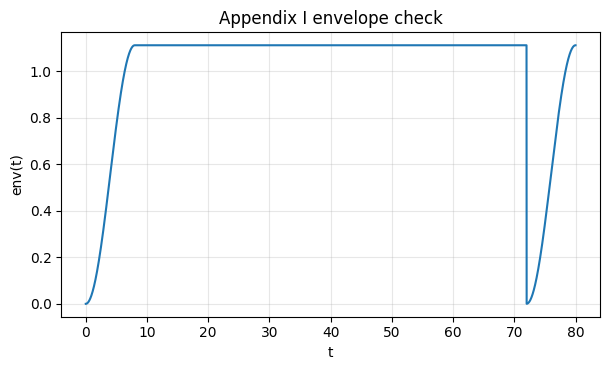

In [4]:

n_env = 4000
t_env = np.linspace(0.0, T_ref, n_env)
env_vals = envelope_i1(t_env, T_ref)
env_area = float(np.trapezoid(env_vals, t_env))
print("Envelope area / T:", env_area / T_ref)

fig = plt.figure(figsize=(6.2, 3.8))
plt.plot(t_env, env_vals)
plt.title("Appendix I envelope check")
plt.xlabel("t")
plt.ylabel("env(t)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "env_check.png", dpi=160)
plt.show()
plt.close(fig)



## 3) Define pulses: vanilla vs improved (Appendix C)

This section visualizes `Omega_vanilla(t)` and `Omega_opt(t)` and applies detuning-phase compensation `-Delta omega_n T / 2` in the optimized phase term.


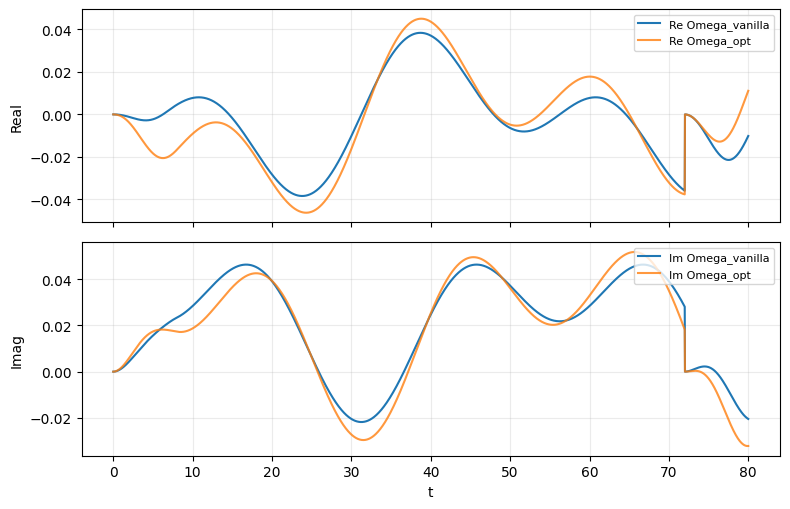

In [5]:

t_trace = np.linspace(0.0, T_ref, 2500)
omega_v = omega_vanilla(t_trace, T_ref, chi, theta)

result_ref = optimize_params(T_ref, theta, chi, CONFIG)
omega_o = omega_optimized(t_trace, T_ref, chi, theta, result_ref["params"])

fig, ax = plt.subplots(2, 1, figsize=(8, 5.2), sharex=True)
ax[0].plot(t_trace, np.real(omega_v), label="Re Omega_vanilla")
ax[0].plot(t_trace, np.real(omega_o), label="Re Omega_opt", alpha=0.8)
ax[0].set_ylabel("Real")
ax[0].grid(alpha=0.25)
ax[0].legend(loc="upper right", fontsize=8)
ax[1].plot(t_trace, np.imag(omega_v), label="Im Omega_vanilla")
ax[1].plot(t_trace, np.imag(omega_o), label="Im Omega_opt", alpha=0.8)
ax[1].set_xlabel("t")
ax[1].set_ylabel("Imag")
ax[1].grid(alpha=0.25)
ax[1].legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "omega_time_trace.png", dpi=160)
plt.show()
plt.close(fig)



## 4) Define and compute the paper fidelity metric (Appendix D)

We compute bounded `F in [0,1]` and `epsilon_coh = 1 - F`, and keep any unbounded norm only as a secondary diagnostic.


In [ ]:

params_zero = PulseParams.zeros(theta.size)
a_v, b_v = manifold_amplitudes(T_ref, theta, chi, params_zero, CONFIG)
m_v = coherent_metric(theta, a_v, b_v)
a_o, b_o = result_ref["a"], result_ref["b"]
m_o = result_ref["metric"]

F_mc_v = fidelity_monte_carlo(theta, a_v, CONFIG["n_mc"], seed=CONFIG["seed"])
F_mc_o = fidelity_monte_carlo(theta, a_o, CONFIG["n_mc"], seed=CONFIG["seed"])

print("Vanilla: F =", m_v["fidelity"], "epsilon_coh =", m_v["epsilon_coh"], "F_mc =", F_mc_v)
print("Optimized: F =", m_o["fidelity"], "epsilon_coh =", m_o["epsilon_coh"], "F_mc =", F_mc_o)
print("Secondary error_vector_norm (diagnostic only): vanilla =", m_v["error_vector_norm"], ", optimized =", m_o["error_vector_norm"])

assert 0.0 <= m_v["fidelity"] <= 1.0
assert 0.0 <= m_o["fidelity"] <= 1.0
assert 0.0 <= m_v["epsilon_coh"] <= 1.0
assert 0.0 <= m_o["epsilon_coh"] <= 1.0
print("Bound checks passed.")



## 5) Compute coherent error components (Appendix B)

This section extracts per-manifold `epsilon_T,n`, `epsilon_L,n`, and `Delta theta_n`, and overlays Lambert-projection estimates (Eq. B2 proxy) before/after optimization.


In [ ]:

alpha = alpha_from_theta(theta)
lam_t_v, lam_l_v = lambert_components(alpha, a_v, b_v)
lam_t_o, lam_l_o = lambert_components(alpha, a_o, b_o)

n_idx = np.arange(theta.size)
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.6))
ax[0].plot(n_idx, np.abs(m_v["eps_t"]), "o-", label="before")
ax[0].plot(n_idx, np.abs(m_o["eps_t"]), "o-", label="after")
ax[0].plot(n_idx, np.abs(lam_t_v), "x--", alpha=0.55, label="before (B2)")
ax[0].plot(n_idx, np.abs(lam_t_o), "x--", alpha=0.55, label="after (B2)")
ax[0].set_title("|epsilon_T,n|")

ax[1].plot(n_idx, np.abs(m_v["eps_l"]), "o-")
ax[1].plot(n_idx, np.abs(m_o["eps_l"]), "o-")
ax[1].plot(n_idx, np.abs(lam_l_v), "x--", alpha=0.55)
ax[1].plot(n_idx, np.abs(lam_l_o), "x--", alpha=0.55)
ax[1].set_title("|epsilon_L,n|")

ax[2].plot(n_idx, np.abs(m_v["dtheta"]), "o-")
ax[2].plot(n_idx, np.abs(m_o["dtheta"]), "o-")
ax[2].set_title("|Delta theta_n|")

for a in ax:
    a.set_xlabel("n")
    a.grid(alpha=0.25)
ax[0].legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIG_DIR / "errors_per_n_before_after.png", dpi=160)
plt.show()
plt.close(fig)



## 6) Implement the iterative optimization loop (Appendix C)

The update in `optimize_params` applies the first-order relationships and backtracking. This section plots the optimization trace and final correction parameters vs manifold index.


In [ ]:

fig = plt.figure(figsize=(6, 4))
plt.plot(np.arange(result_ref["history_eps"].size), result_ref["history_eps"], "o-")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("epsilon_coh = 1 - F")
plt.title("Optimization trace at T_ref")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "opt_trace.png", dpi=160)
plt.show()
plt.close(fig)

p = result_ref["params"]
fig, ax = plt.subplots(3, 1, figsize=(6, 6.8), sharex=True)
ax[0].plot(n_idx, p.dlam, "o-")
ax[0].set_ylabel("Delta lambda_n")
ax[1].plot(n_idx, p.dw, "o-")
ax[1].set_ylabel("Delta omega_n")
ax[2].plot(n_idx, p.da, "o-")
ax[2].set_ylabel("Delta alpha_n")
ax[2].set_xlabel("n")
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "params_vs_n.png", dpi=160)
plt.show()
plt.close(fig)



## 7) Reproduce the optimization limit (Table I style)

We sweep `chi T` and estimate
`T_opt = min{T: epsilon_coh(T) < epsilon_target within iteration cap}`.


In [ ]:

durations = [float(x) for x in CONFIG["durations"]]
chiT = np.asarray(durations) * chi
eps_v = []
eps_o = []
sweep_results = {}

for T in durations:
    a0, b0 = manifold_amplitudes(T, theta, chi, PulseParams.zeros(theta.size), CONFIG)
    m0 = coherent_metric(theta, a0, b0)
    ro = optimize_params(T, theta, chi, CONFIG)
    eps_v.append(m0["epsilon_coh"])
    eps_o.append(ro["metric"]["epsilon_coh"])
    sweep_results[T] = ro

eps_target = float(CONFIG["epsilon_target"])
T_opt = None
for T, e in zip(durations, eps_o):
    if e < eps_target:
        T_opt = T
        break
if T_opt is None:
    T_opt = durations[-1]

idx_opt = durations.index(T_opt)
T_below = durations[max(0, idx_opt - 1)]

print("epsilon_target:", eps_target)
print("T_below:", T_below, "eps_opt(T_below)=", eps_o[max(0, idx_opt - 1)])
print("T_opt:", T_opt, "eps_opt(T_opt)=", eps_o[idx_opt])
print("Threshold hit above and not below:", eps_o[idx_opt] < eps_target, eps_o[max(0, idx_opt - 1)] >= eps_target)

fig = plt.figure(figsize=(6.6, 4.2))
plt.plot(chiT / np.pi, eps_v, "o-", label="vanilla")
plt.plot(chiT / np.pi, eps_o, "o-", label="optimized")
plt.axhline(eps_target, color="tab:red", linestyle="--", label="epsilon_target")
plt.axvline((chi * T_opt) / np.pi, color="tab:green", linestyle=":", label="chi T_opt / pi")
plt.yscale("log")
plt.xlabel("chi T / pi")
plt.ylabel("epsilon_coh")
plt.title("Optimization-limit sweep")
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fidelity_vs_chiT.png", dpi=160)
plt.show()
plt.close(fig)



## 8) Tone-family preservation (spectrum check)

We overlay FFT spectra and report out-of-set leakage ratio `r_out`.
Windowing: Hann. Frequency resolution: `df = 1 / T_total` equivalent from FFT bins.


In [ ]:

run_above = sweep_results[T_opt]
params_above = run_above["params"]
t_fft = np.linspace(0.0, T_opt, int(CONFIG["fft_bins"]), endpoint=False)

omega_v_fft = omega_vanilla(t_fft, T_opt, chi, theta)
omega_o_fft = omega_optimized(t_fft, T_opt, chi, theta, params_above)

allowed_v = np.asarray([chi * n for n in range(theta.size)], dtype=float)
allowed_o = np.asarray([chi * n + params_above.dw[n] for n in range(theta.size)], dtype=float)

leak_v = out_of_set_leakage(t_fft, omega_v_fft, allowed_v, neighbor_bins=int(CONFIG["spectrum_neighbor_bins"]))
leak_o = out_of_set_leakage(t_fft, omega_o_fft, allowed_o, neighbor_bins=int(CONFIG["spectrum_neighbor_bins"]))

print("r_out vanilla:", leak_v["r_out"])
print("r_out optimized:", leak_o["r_out"])
print("FFT df (Hz-equivalent in model units):", leak_o["df"])

fig = plt.figure(figsize=(7.2, 4.3))
plt.plot(leak_v["omega"], leak_v["power_norm"], label="vanilla", alpha=0.8)
plt.plot(leak_o["omega"], leak_o["power_norm"], label="optimized", alpha=0.8)
for w in allowed_o:
    plt.axvline(w, color="k", alpha=0.15, linewidth=1)
    plt.axvline(-w, color="k", alpha=0.15, linewidth=1)
plt.xlabel("Angular frequency")
plt.ylabel("Normalized power")
plt.title("Spectrum overlay and allowed tone family")
plt.grid(alpha=0.2)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "spectrum_overlay.png", dpi=160)
plt.show()
plt.close(fig)



## 9) Numerical convergence checks

Timestep refinement check: halve `dt` and verify bounded metric changes negligibly.


In [ ]:

cfg_fine = dict(CONFIG)
cfg_fine["dt"] = CONFIG["dt"] * 0.5

m_coarse = run_above["metric"]
a_fine, b_fine = manifold_amplitudes(T_opt, theta, chi, params_above, cfg_fine)
m_fine = coherent_metric(theta, a_fine, b_fine)

print("coarse fidelity:", m_coarse["fidelity"], "coarse epsilon:", m_coarse["epsilon_coh"])
print("fine fidelity:", m_fine["fidelity"], "fine epsilon:", m_fine["epsilon_coh"])
print("relative fidelity difference:", abs(m_fine["fidelity"] - m_coarse["fidelity"]) / max(abs(m_fine["fidelity"]), 1e-15))

fig = plt.figure(figsize=(5.8, 4.0))
labels = ["coarse dt", "fine dt"]
vals = [m_coarse["fidelity"], m_fine["fidelity"]]
plt.bar(labels, vals, color=["#355C7D", "#C06C84"])
plt.ylabel("Fidelity F")
plt.ylim(max(0.0, min(vals) - 5e-3), 1.0001)
plt.title("Timestep refinement check")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "convergence_dt.png", dpi=160)
plt.show()
plt.close(fig)


## PASS checklist summary

The dictionary below captures the strict PASS signals requested in the protocol.


In [ ]:

summary = {
    "metric_bounds_vanilla": bool(0.0 <= m_v["fidelity"] <= 1.0 and 0.0 <= m_v["epsilon_coh"] <= 1.0),
    "metric_bounds_optimized": bool(0.0 <= m_o["fidelity"] <= 1.0 and 0.0 <= m_o["epsilon_coh"] <= 1.0),
    "epsilon_target": eps_target,
    "T_opt": T_opt,
    "eps_opt_below": float(eps_o[max(0, idx_opt - 1)]),
    "eps_opt_at_Topt": float(eps_o[idx_opt]),
    "threshold_hit_above": bool(eps_o[idx_opt] < eps_target),
    "threshold_not_hit_below": bool(eps_o[max(0, idx_opt - 1)] >= eps_target),
    "max_component_before": float(max(np.max(np.abs(m_v["dtheta"])), np.max(np.abs(m_v["eps_l"])), np.max(np.abs(m_v["eps_t"])))),
    "max_component_after": float(max(np.max(np.abs(m_o["dtheta"])), np.max(np.abs(m_o["eps_l"])), np.max(np.abs(m_o["eps_t"])))),
    "r_out_optimized": float(leak_o["r_out"]),
    "r_out_vanilla": float(leak_v["r_out"]),
    "fidelity_coarse": float(m_coarse["fidelity"]),
    "fidelity_fine": float(m_fine["fidelity"]),
    "required_figures": [
        "env_check.png",
        "omega_time_trace.png",
        "fidelity_vs_chiT.png",
        "opt_trace.png",
        "errors_per_n_before_after.png",
        "params_vs_n.png",
        "spectrum_overlay.png",
        "convergence_dt.png",
    ],
}

print(json.dumps(summary, indent=2))

with (OUTPUT_DIR / "landgraf_notebook_summary.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved summary to", OUTPUT_DIR / "landgraf_notebook_summary.json")
print("Saved figures in", FIG_DIR)
